In [12]:
import pandas as pd
import numpy as np

def compute_signals(
    historical_temps: pd.DataFrame,
    threshold_f: float = 85.0,
    lookback_days: int = 30,
    market_noise: float = 0.05,
) -> pd.DataFrame:
    """
    Estimate p(daily high > threshold_f) using a rolling historical window.
    Args:
        historical_temps: DataFrame with columns 'DATE' (datetime) and 'TMAX' (°F)
        threshold_f:      temperature threshold (e.g. 85°F for LA in summer)
        lookback_days:    rolling window to estimate climatology probability
        market_noise:     std of Gaussian noise added to market_price (simulates
                          market not tracking forecast perfectly)
    Returns:
        DataFrame with columns: date, p_model, market_price, resolved_yes
    Implementation hints:
        1. Sort by DATE. For each day i, look at the last lookback_days days.
        2. p_model = (number of days in window where TMAX > threshold_f) / lookback_days
           This is a rolling empirical probability — your "model."
        3. resolved_yes = 1 if that day's TMAX > threshold_f, else 0.
        4. market_price = 0.50 + random noise (mean 0, std=market_noise, clipped to [0.05, 0.95])
           This simulates a naive market. Better: use actual Kalshi prices from
           data/features/snapshots.parquet if you want a more realistic test.
        5. Return one row per day where abs(p_model - market_price) > 0.05 (min edge filter).
    """
    # 1. Make a copy and sort by DATE
    df = historical_temps.copy()
    df = df.sort_values("DATE").reset_index(drop=True)
    
    # Ensure TMAX is numeric
    df["TMAX"] = pd.to_numeric(df["TMAX"], errors="coerce")
    
    # 2. Compute rolling p_model (empirical probability)
    # For each day, count how many days in the last lookback_days had TMAX > threshold_f
    df["exceeds_threshold"] = (df["TMAX"] > threshold_f).astype(int)
    df["p_model"] = df["exceeds_threshold"].rolling(
        window=lookback_days, min_periods=1
    ).mean()
    
    # 3. Compute resolved_yes (actual outcome for that day)
    df["resolved_yes"] = df["exceeds_threshold"]
    
    # 4. Generate market_price with noise
    # Start with base 0.50, add Gaussian noise, clip to [0.05, 0.95]
    # np.random.seed(42)  # For reproducibility; remove if you want different runs
    noise = np.random.normal(loc=0, scale=market_noise, size=len(df))
    df["market_price"] = 0.50 + noise
    df["market_price"] = df["market_price"].clip(0.05, 0.95)
    
    # 5. Filter for meaningful edge (abs difference > 0.05) and return
    df["edge"] = np.abs(df["p_model"] - df["market_price"])
    signals = df[df["edge"] > 0.05][["p_model", "market_price", "resolved_yes"]].copy()
    
    return signals.reset_index(drop=True)

In [21]:
import sys, pathlib
sys.path.insert(0, r"C:\Users\Evan\Documents\projects\acm\ACM-AI-Spring-2026-Prediction-Markets")

from execution.kelly import kelly_fraction, dollars_to_contracts
from backtest.metrics import compute_metrics, print_metrics

dates = pd.date_range("2022-01-01", periods=100, freq="D")
temps = np.random.uniform(50, 90, size=100)
sample_df = pd.DataFrame({"DATE": dates, "TMAX": temps})

# Run the function
signals = compute_signals(sample_df, threshold_f=75.0, lookback_days=30)
# ─────────────────────────────────────────────────────────────────────────────

STARTING_BALANCE = 1000.0
balance = STARTING_BALANCE
cumulative_pnl = 0.0
trades = []

for _, row in signals.iterrows():
    bet_dollars, side = kelly_fraction(
        p_model=row["p_model"],
        market_price=row["market_price"],
        bankroll=balance,
        kelly_multiplier=0.25,
        max_position_pct=0.05,
    )
    if bet_dollars <= 0:
        continue

    price = row["market_price"] if side == "YES" else (1 - row["market_price"])
    n_contracts = dollars_to_contracts(bet_dollars, price)
    if n_contracts == 0:
        continue

    cost = n_contracts * price
    won = (side == "YES" and row["resolved_yes"] == 1) or \
          (side == "NO" and row["resolved_yes"] == 0)
    pnl = n_contracts * (1 - price) if won else -cost
    balance += pnl
    cumulative_pnl += pnl

    trades.append({
        "p_model": row["p_model"],
        "market_price": row["market_price"],
        "side": side,
        "n_contracts": n_contracts,
        "cost": round(cost, 4),
        "edge": round(abs(row["p_model"] - row["market_price"]), 4),
        "resolved_yes": row["resolved_yes"],
        "won": won,
        "pnl": round(pnl, 4),
        "balance": round(balance, 2),
        "cumulative_pnl": round(cumulative_pnl, 4),
    })

trades_df = pd.DataFrame(trades)
print_metrics(trades_df, starting_balance=STARTING_BALANCE)


  BACKTEST RESULTS
  Trades          : 88
  Total P&L       : $+4737.97
  ROI             : +473.80%
  Win Rate        : 67.0%  ✅
  Avg Edge        : 0.1784
  Sharpe Ratio    : 5.115  ✅
  Sortino Ratio   : 12.450
  Max Drawdown    : $-677.26 (-67.7%)

  Week 6 Decision: ❌ Stay in dry-run — review strategy



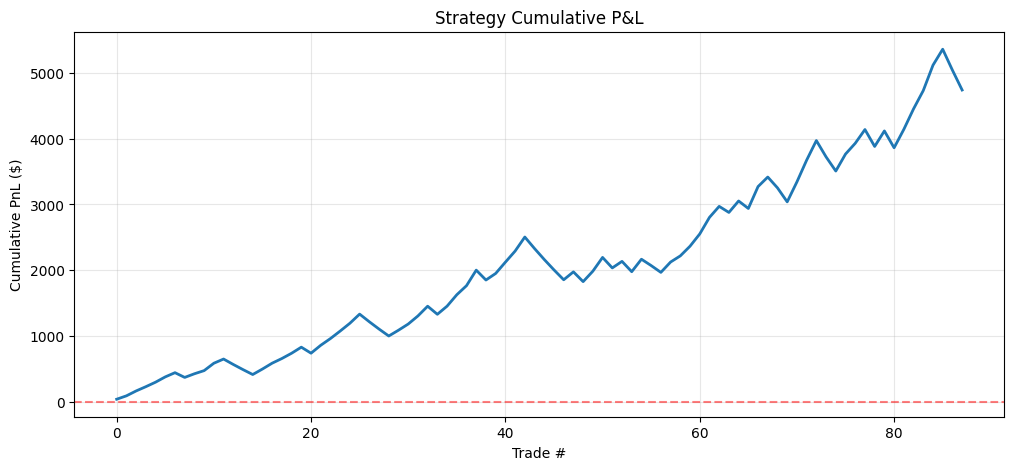

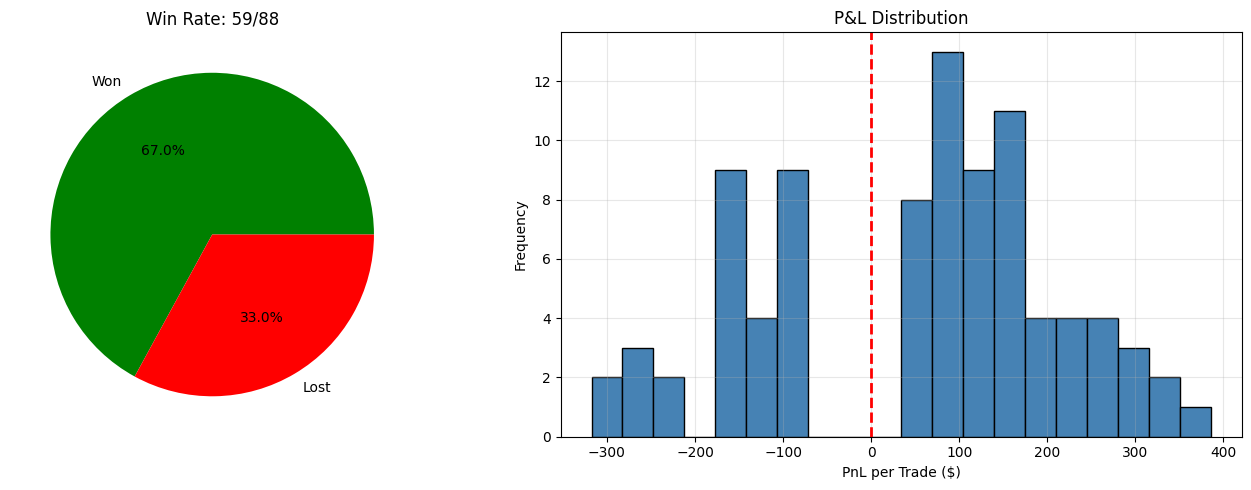

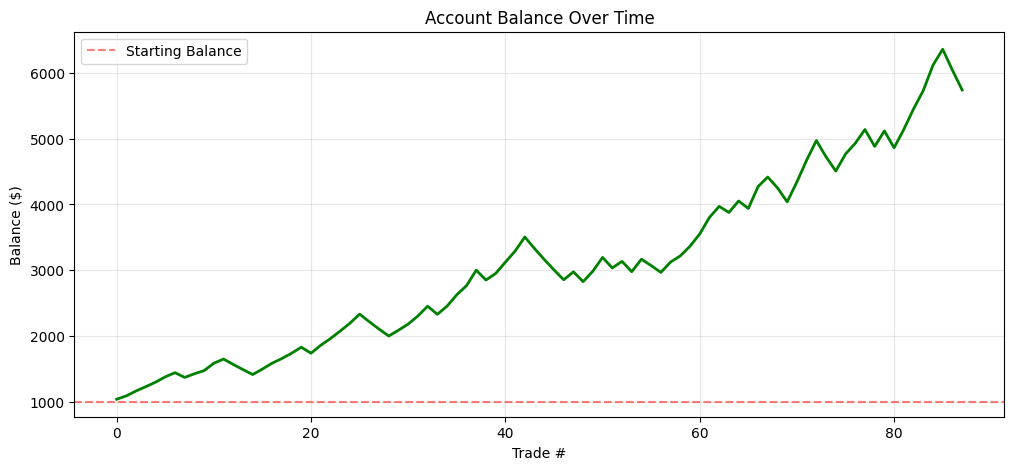

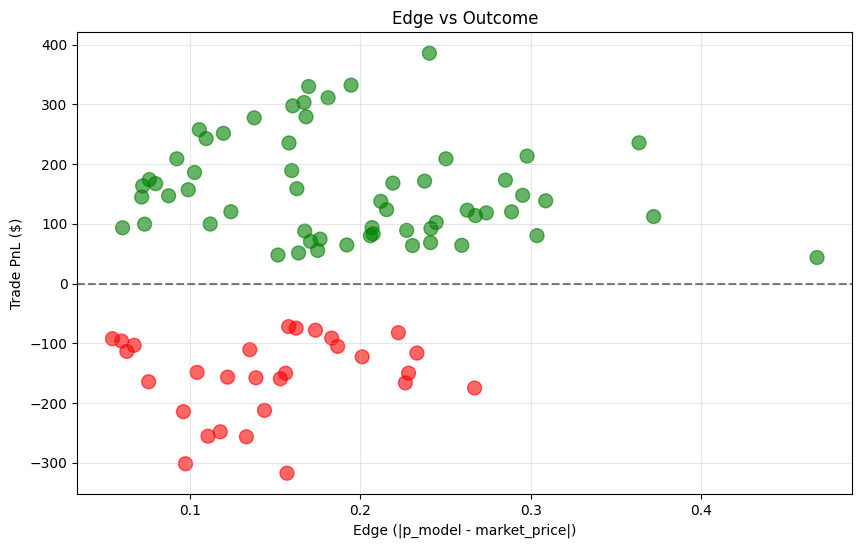


Total Trades: 88
Win Rate: 67.0%
Total P&L: $4737.97
Avg P&L per Trade: $53.84
Max Drawdown: $43.51
Final Balance: $5737.97


In [22]:
import matplotlib.pyplot as plt

# 1. Cumulative PnL over time
plt.figure(figsize=(12, 5))
plt.plot(trades_df["cumulative_pnl"], linewidth=2)
plt.axhline(y=0, color="red", linestyle="--", alpha=0.5)
plt.xlabel("Trade #")
plt.ylabel("Cumulative PnL ($)")
plt.title("Strategy Cumulative P&L")
plt.grid(True, alpha=0.3)
plt.show()

# 2. Win rate and trade outcomes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Win rate pie chart
win_count = trades_df["won"].sum()
loss_count = len(trades_df) - win_count
ax1.pie([win_count, loss_count], labels=["Won", "Lost"], autopct="%1.1f%%", colors=["green", "red"])
ax1.set_title(f"Win Rate: {win_count}/{len(trades_df)}")

# PnL distribution
ax2.hist(trades_df["pnl"], bins=20, edgecolor="black", color="steelblue")
ax2.axvline(x=0, color="red", linestyle="--", linewidth=2)
ax2.set_xlabel("PnL per Trade ($)")
ax2.set_ylabel("Frequency")
ax2.set_title("P&L Distribution")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Balance over time
plt.figure(figsize=(12, 5))
plt.plot(trades_df["balance"], linewidth=2, color="green")
plt.axhline(y=STARTING_BALANCE, color="red", linestyle="--", label="Starting Balance", alpha=0.5)
plt.xlabel("Trade #")
plt.ylabel("Balance ($)")
plt.title("Account Balance Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Edge vs Outcome
plt.figure(figsize=(10, 6))
colors = ["green" if w else "red" for w in trades_df["won"]]
plt.scatter(trades_df["edge"], trades_df["pnl"], c=colors, alpha=0.6, s=100)
plt.xlabel("Edge (|p_model - market_price|)")
plt.ylabel("Trade PnL ($)")
plt.title("Edge vs Outcome")
plt.axhline(y=0, color="black", linestyle="--", alpha=0.5)
plt.grid(True, alpha=0.3)
plt.show()

# 5. Summary stats
print(f"\n{'='*50}")
print(f"Total Trades: {len(trades_df)}")
print(f"Win Rate: {trades_df['won'].sum() / len(trades_df):.1%}")
print(f"Total P&L: ${trades_df['pnl'].sum():.2f}")
print(f"Avg P&L per Trade: ${trades_df['pnl'].mean():.2f}")
print(f"Max Drawdown: ${(trades_df['balance'].min() - STARTING_BALANCE):.2f}")
print(f"Final Balance: ${trades_df['balance'].iloc[-1]:.2f}")
print(f"{'='*50}")